# Retrieval and RAG over tasting notes

Retrieval asks a different question from the models so far: not "what does this prose imply about
price" but "what did wines that taste like this actually cost".

The store holds tasting notes only. No price, no critic score, no winery in the embedded text -- if
those went in, similarity search would find the answer instead of a comparable wine, and the whole
evaluation would be a leak with extra steps. Prices live in the metadata, retrieved *after* the
match, which is how a comparable is supposed to work.

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

from pricer import vectors
from pricer.agents import ClassicalAgent, FrontierAgent, NeighboursAgent, price_all, setup_logging
from pricer.evaluator import Report, leaderboard
from pricer.items import Wine

setup_logging()
train, val, test = Wine.load_local()
collection = vectors.load()  # built by scripts/vectors.py
encoder = vectors.encoder()
print(f"{collection.count():,} tasting notes embedded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

82,786 tasting notes embedded


### Does the embedding space know about price?

If wines that taste alike also cost alike, the neighbourhood structure carries price information and
retrieval will help. Colour a t-SNE projection by price and look for gradient rather than noise.

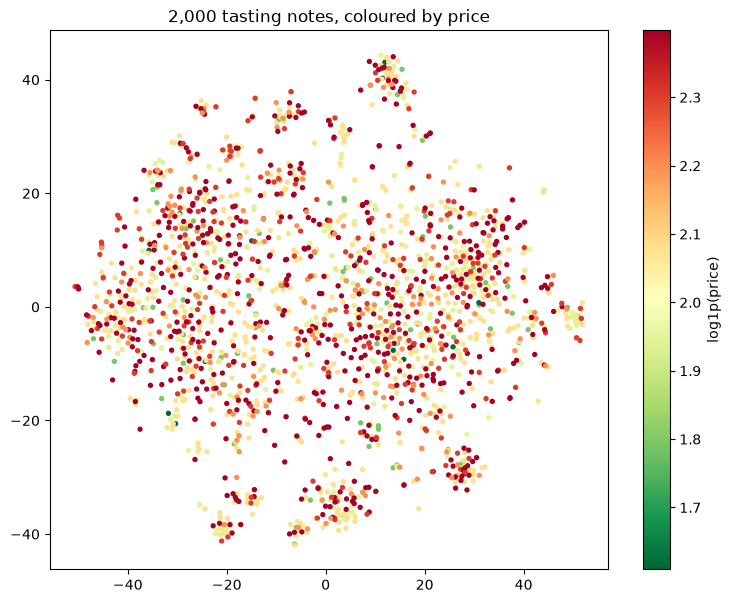

Most common varieties in the sample: [('Chardonnay', 208), ('Cabernet Sauvignon', 169), ('Sauvignon Blanc', 138), ('Portuguese Red', 133), ('Merlot', 130)]


In [2]:
embeddings, prices, varieties = vectors.sample_coordinates(collection, limit=2_000)
flat = TSNE(n_components=2, random_state=42, init="pca", perplexity=30).fit_transform(embeddings)
plt.figure(figsize=(9, 7))
points = plt.scatter(flat[:, 0], flat[:, 1], c=np.log1p(prices), cmap="RdYlGn_r", s=8)
plt.colorbar(points, label="log1p(price)")
plt.title("2,000 tasting notes, coloured by price")
plt.show()
print("Most common varieties in the sample:", Counter(varieties).most_common(5))

### What does retrieval return for one wine?

In [3]:
wine = test[7]
notes, found = vectors.similar(wine.description, collection, encoder, k=5)
print(f"{wine.label} -- actually ${wine.price:.0f}\n")
for note, price in zip(notes, found, strict=True):
    print(f"${price:>6.0f}  {note[:110]}...")
print(f"\ngeometric mean of the neighbours: ${np.expm1(np.log1p(found).mean()):.2f}")

Porta Syrah -- actually $15

$    13  Slightly citric on the nose, with bouncy, edgy fruit flavors of strawberry and raspberry. It's a lightweight w...
$    13  This medium-bodied wine shows almost tobacco-like scents to go along with tropical fruit on the nose. It's lea...
$     6  The nose smells a bit like corn. The wine is round, soft and without much edge. The fruit seems a little pliab...
$    22  This wine, made by Native American descendent Tara Gomez from the Chumash tribe, is dynamic on the nose. It sh...
$    21  A wine with faults and a few positives. On the nose, it's roasted almost to the point of being overdone. It sm...

geometric mean of the neighbours: $13.73


### Retrieval alone, then retrieval plus a language model

Two agents, one question each. `NeighboursAgent` is pure retrieval: the geometric mean of the k
nearest prices, no LLM. `FrontierAgent` puts the same neighbours in a prompt and asks a model for a
number. The gap between them is what the language model contributes over the lookup; if it is small,
the expensive part is not earning its keep.

100 test wines, because the frontier agent goes over the network for each one. Note the sample size in
the leaderboard: these rows are not comparable to the 2,000-wine baseline rows, only to each other.

The classical agent here is the **note-only** model, not the metadata-aware baseline. An agent receives prose and
nothing else, so feeding the metadata-aware pipeline `variety='unknown', vintage=0` at inference --
after fitting it on the real values -- cost about 0.2 RMSLE. Train on what you can actually serve.

In [4]:
sample = test[:100]
neighbours = NeighboursAgent(collection, encoder)
classical = ClassicalAgent()

for name, agent in [("Neighbours (k=8, retrieval only)", neighbours), ("Classical (note only)", classical)]:
    guesses = [agent.price(w.description) for w in sample]
    Report(name, [w.label for w in sample], guesses, [w.price for w in sample]).save()

frontier = FrontierAgent(collection, encoder)
guesses = price_all(frontier, [w.description for w in sample])  # stops early if the daily quota runs out
scored = sample[: len(guesses)]
if scored:
    Report("Frontier (RAG + LLM)", [w.label for w in scored], guesses, [w.price for w in scored]).save()
leaderboard()

12:46:36 [Neighbours Agent] Connecting to the Chroma store


12:46:36 [Neighbours Agent] Ready with 82,786 notes


12:46:36 [Classical Agent] Loading the TF-IDF + Ridge model


12:46:36 [Classical Agent] Ready


12:46:37 [Frontier Agent] Setting up with groq


...

12:54:32 [Frontier Agent] Retrieved 5 comparable wines priced $25-$30


12:54:38 [Frontier Agent] Estimated $28.00


12:54:38 [Frontier Agent] Retrieved 5 comparable wines priced $10-$48


12:54:43 [Frontier Agent] Estimated $22.00


model                                    MAE    RMSLE      R2    hits      n
Tf-Idf + Ridge                        12.80    0.415   57.9%   62.4%    250
TF-IDF + Ridge                        12.82    0.423   38.3%   63.6%  2,000
Lsa + Random Forest                   13.50    0.445   39.7%   60.4%    250
Classical (note only)                 14.40    0.454   56.1%   57.0%    100
LSA + Random Forest                   13.42    0.454   31.9%   60.0%  2,000
Metadata + Linear Regression          14.84    0.483   33.8%   58.8%    250
Neighbours (k=8, retrieval only)      17.55    0.588   17.9%   53.0%    100
Frontier (RAG + LLM)                  16.79    0.656   34.2%   55.0%    100
Constant $30                          19.99    0.670   -3.2%   35.2%    250


### Experiments worth running here

- Sweep `k` in `NeighboursAgent`. Too few neighbours is noisy, too many regresses to the mean.
- Weight the neighbours by similarity instead of averaging them flat.
- Retrieve on the LLM summary instead of the full note (`scripts/tasting.py` first) and see whether a
  tighter, more structured text retrieves better comparables.
- Embed with a bigger encoder (`all-mpnet-base-v2`) and measure whether the extra dimensions pay.
- Give the frontier agent the neighbours' varieties and regions too, and see if context helps or
  just distracts it.